# Spatial CellChat analysis of human psoriatic skin (Python)

**Corresponds to:** R tutorial `SpatialCellChat_analysis_of_spatial_transcriptomics_data.Rmd`  
**Python package:** `CellChatPy`  
**Dataset:** 10X Visium human psoriatic skin section from Ma et al. (2023)

This tutorial follows the SpatialCellChat workflow with CellChatPy: spatially
variable signaling-gene selection, communication inference between individual
spots, Visium proportion-based aggregation to deconvolved cell groups, spatial
hotspot analysis, Lee spatial co-occurrence, and communication-topic analysis.

CellChatPy keeps the two analysis resolutions separate. `spot_network` and
`spot_pathway_network` contain sparse spot-by-spot results. `network` and
`pathway_network` contain the group-level results obtained after aggregation
with the deconvolved Visium proportions.

The Python implementation uses analytical Moran's I and scikit-learn NMF in
place of the corresponding R backends. They fill the same analytical roles,
but their numerical results need not match the R tutorial value by value.

## Setup & Imports

In [1]:
import os, pickle, sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.spatial.distance import pdist
from IPython.display import display
%matplotlib inline

project_root = Path(os.getcwd()).resolve().parent if Path(os.getcwd()).name == "tutorial" else Path(os.getcwd()).resolve()
if not (project_root / "CellChatPy").is_dir():
    raise FileNotFoundError(
        f"CellChatPy package was not found under the project root: {project_root}"
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import CellChatPy as cc

h5_path = project_root / "data" / "human_psoriasis.h5"
TUTORIAL_DIR = (project_root / "tutorial").resolve()
OUT_DIR = (TUTORIAL_DIR / "figures_spatial_transcriptomics").resolve()
output_dir = (TUTORIAL_DIR / "spatial_tutorial_output").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

interaction_range_um = 250.0
contact_range_um = 10.0
spot_filter_n_boot = 100
spot_filter_seed = 666
group_n_boot = 100
group_seed = 1
topic_seed = 666
topic_count = 12

if not h5_path.exists():
    raise FileNotFoundError(f"Required spatial H5 input was not found: {h5_path}")


def save_fig(fig, filename: str, dpi: int = 180) -> None:
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {filename} returned None")
        return None
    path = OUT_DIR / filename
    try:
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc
    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)


print(f"CellChatPy:        {Path(cc.__file__).resolve()}")
print(f"Input H5:         {h5_path}")
print(f"Figures directory: {OUT_DIR}")
print(f"Results directory: {output_dir}")
print(f"Spot filter bootstrap runs:  {spot_filter_n_boot}")
print(f"Group aggregation bootstrap runs: {group_n_boot}")

CellChatPy:        E:\Jin\cellchat.python_new\CellChatPy\__init__.py
Input H5:         E:\Jin\cellchat.python_new\data\human_psoriasis.h5
Figures directory: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics
Results directory: E:\Jin\cellchat.python_new\tutorial\spatial_tutorial_output
Spot filter bootstrap runs:  100
Group aggregation bootstrap runs: 100


---
## Part I: Data Input & Processing and Initialization of CellChat Object

Load the spatial expression matrix, align metadata and coordinates, normalize
the data, and initialize a spatial CellChatPy object.

### Load and validate the Visium input

`read_spatial_h5` returns a canonical cells-by-genes expression matrix and
aligned metadata, coordinates, physical conversion factors, deconvolution
proportions, and optional image fields. No dataset-specific reader is needed.

In [2]:
visium = cc.read_spatial_h5(h5_path)
counts = visium["expression"]
genes = visium["genes"]
spot_ids = visium["cells"]
metadata = visium["metadata"].copy()
coordinates = visium["coordinates"].copy()
predictions_raw = visium["predictions"].copy()
predictions = predictions_raw.copy()
predictions[predictions < 0.1] = 0.0
spatial_factors = visium["spatial_factors"]

pixel_to_um = float(spatial_factors["ratio"][0])
nearest_center_um = pdist(coordinates.to_numpy()).min() * pixel_to_um

assert counts.shape == (905, 33538)
assert len(genes) == counts.shape[1]
assert metadata.index.tolist() == spot_ids
assert predictions.index.tolist() == spot_ids
assert np.isfinite(predictions.to_numpy()).all()
assert (predictions.to_numpy() >= 0).all()

print(f"Expression: {counts.shape[0]:,} spots x {counts.shape[1]:,} genes")
print(f"Clusters:   {metadata['cellchat_group'].value_counts().to_dict()}")
print(f"1 pixel:    {pixel_to_um:.6f} um")
print(f"Nearest spot-center distance: {nearest_center_um:.2f} um")
display(predictions.describe().T[["min", "mean", "max"]])

Expression: 905 spots x 33,538 genes
Clusters:   {'Keratinocyte': 247, 'EG': 181, 'SM': 154, 'FIB': 130, 'ENDO': 113, 'Immune': 80}
1 pixel:    0.379117 um
Nearest spot-center distance: 99.71 um


,min,mean,max
FIB,0.0,0.118464,0.999651
ENDO,0.0,0.129395,0.986726
SM,0.0,0.162439,1.000000
EG,0.0,0.170793,1.000000
Keratinocyte,0.0,0.242918,1.000000
Immune,0.0,0.132764,1.000000


### Normalize counts and create a spatial CellChat object

In [3]:
normalized = cc.normalize_data(counts, scale_factor=1e4, do_log=True, do_sparse=True)
assert sparse.isspmatrix_csr(normalized)

cellchat = cc.create_cellchat(
    normalized,
    genes=genes,
    cells=spot_ids,
    metadata=metadata,
    group_by="cellchat_group",
    datatype="spatial",
    coordinates=coordinates,
    spatial_factors=spatial_factors,
)
print(cellchat)
print("Spatial factors:", cellchat.spatial["spatial_factors"])

Create a CellChat object from a data matrix
Cell groups used for CellChat analysis: ['EG', 'ENDO', 'FIB', 'Immune', 'Keratinocyte', 'SM']
Create a CellChat object from spatial transcriptomics data...
An object of class CellChat created from a single dataset
33538 genes, 905 cells
CellChat analysis of SPATIAL data!
The input spatial locations are:
                          0        1
AAACCGGGTAGGTACC-1  10949.0  11251.0
AAACCGTTCGTCCAGG-1   9103.0  13546.0
AAACCTCATGAAGTTG-1  12135.0  10103.0
AAACGAGACGGTTGAT-1   4222.0   9648.0
AAACTTGCAAACGTAT-1  12136.0  11939.0
Spatial factors: {'ratio': [0.37911718561304986], 'tol': [32.5]}


### Spatial annotations and Visium cell-type proportions

The first panel shows discrete spot annotations. The second shows continuous
cell-type proportions, which are later used directly for group aggregation.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\01_spatial_clusters.png


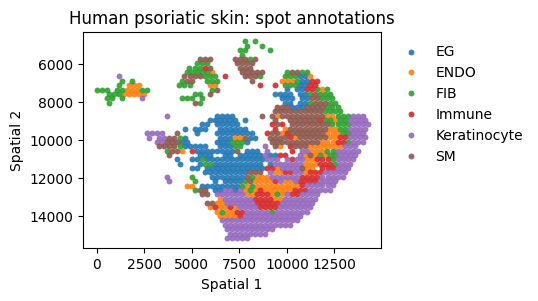

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\02_deconvolution_proportions.png


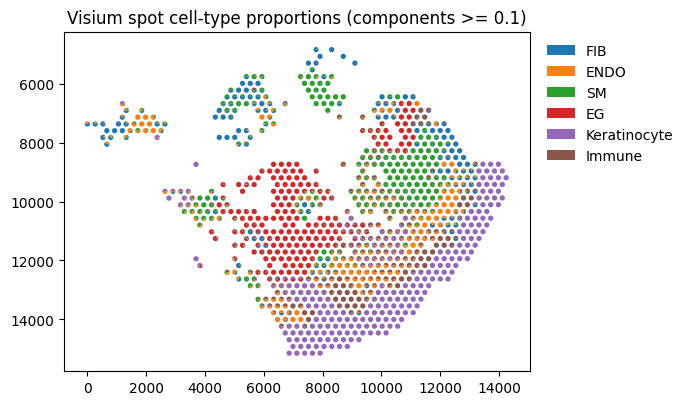

In [4]:
fig = cc.plot_spatial_categories(
    cellchat, "cellchat_group", point_size=18,
    title="Human psoriatic skin: spot annotations", return_fig=True,
)
save_fig(fig, "01_spatial_clusters.png")

fig = cc.plot_spatial_proportions(
    cellchat, predictions, min_fraction=0.1,
    title="Visium spot cell-type proportions (components >= 0.1)", return_fig=True,
)
save_fig(fig, "02_deconvolution_proportions.png")

### Select CellChatDB interactions

As in the R tutorial, the analysis includes protein-mediated Secreted
Signaling, ECM-Receptor, and Cell-Cell Contact interactions. Non-protein
signaling is excluded because it requires measurements beyond expression.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\03_database_categories.png


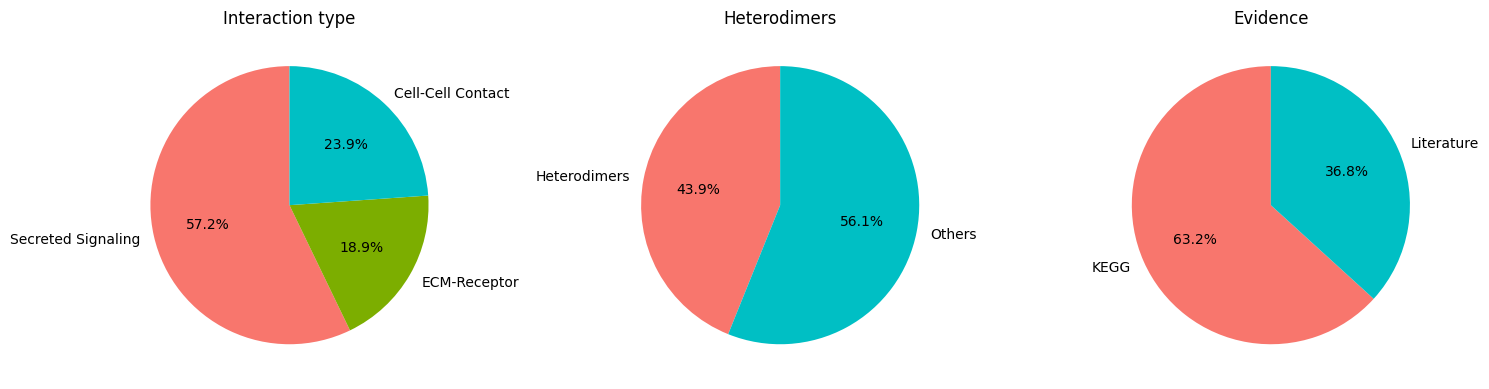

Database interactions used: 2,239


,interaction_name,pathway_name,ligand,receptor,annotation
TGFB1_TGFBR1_TGFBR2,TGFB1_TGFBR1_TGFBR2,TGFb,TGFB1,TGFbR1_R2,Secreted Signaling
TGFB2_TGFBR1_TGFBR2,TGFB2_TGFBR1_TGFBR2,TGFb,TGFB2,TGFbR1_R2,Secreted Signaling
TGFB3_TGFBR1_TGFBR2,TGFB3_TGFBR1_TGFBR2,TGFb,TGFB3,TGFbR1_R2,Secreted Signaling
TGFB1_ACVR1B_TGFBR2,TGFB1_ACVR1B_TGFBR2,TGFb,TGFB1,ACVR1B_TGFbR2,Secreted Signaling
TGFB1_ACVR1C_TGFBR2,TGFB1_ACVR1C_TGFBR2,TGFb,TGFB1,ACVR1C_TGFbR2,Secreted Signaling
TGFB2_ACVR1B_TGFBR2,TGFB2_ACVR1B_TGFBR2,TGFb,TGFB2,ACVR1B_TGFbR2,Secreted Signaling
TGFB2_ACVR1C_TGFBR2,TGFB2_ACVR1C_TGFBR2,TGFb,TGFB2,ACVR1C_TGFbR2,Secreted Signaling
TGFB3_ACVR1B_TGFBR2,TGFB3_ACVR1B_TGFBR2,TGFb,TGFB3,ACVR1B_TGFbR2,Secreted Signaling
TGFB3_ACVR1C_TGFBR2,TGFB3_ACVR1C_TGFBR2,TGFb,TGFB3,ACVR1C_TGFbR2,Secreted Signaling
TGFB1_ACVR1_TGFBR1,TGFB1_ACVR1_TGFBR1,TGFb,TGFB1,ACVR1_TGFbR,Secreted Signaling


In [5]:
db_human = cc.load_database("human")
db_use = cc.subset_database(
    db_human,
    search=["Secreted Signaling", "ECM-Receptor", "Cell-Cell Contact"],
    non_protein=False,
)
cellchat = cc.set_database(cellchat, database=db_use)

fig = cc.show_database_category(db_use)
save_fig(fig, "03_database_categories.png")
print(f"Database interactions used: {len(db_use['interaction']):,}")
display(db_use["interaction"][[
    "interaction_name", "pathway_name", "ligand", "receptor", "annotation"
]].head(10))

### Spatially variable signaling genes and candidate L-R pairs

Analytical Moran's I is calculated on a 12-nearest-neighbour graph. An L-R
pair is retained when either its ligand or receptor side is supported
(`variable_both=False`), matching the R tutorial's selection rule.

In [6]:
analysis_start = time.time()
cellchat = cc.subset_signaling_data(cellchat)
cellchat = cc.identify_spatially_variable_genes(
    cellchat, n_neighbors=12, thresh_p=0.05, min_spots=10,
)
cellchat = cc.identify_overexpressed_interactions(cellchat, variable_both=False)

variable_gene_table = cellchat.feature_results["features_info"]
lr_candidates = cellchat.lr_pairs["significant"]
variable_gene_table.to_csv(output_dir / "spatially_variable_signaling_genes.csv", index=False)
lr_candidates.to_csv(output_dir / "candidate_ligand_receptor_pairs.csv", index=False)

print(f"Signaling genes in expression layer: {cellchat.signaling.shape[1]:,}")
print(f"Spatially variable signaling genes: {len(cellchat.feature_results['features']):,}")
print(f"Candidate L-R pairs: {len(lr_candidates):,}")
display(variable_gene_table.head(10))
display(lr_candidates[["interaction_name", "pathway_name", "annotation"]].head(10))

The number of highly variable ligand-receptor pairs used for signaling inference is 1624
Signaling genes in expression layer: 33,538
Spatially variable signaling genes: 430
Candidate L-R pairs: 1,624


,features,observed,expected,z_score,pvalues,pvalues_adj,n_spots
0,COL1A2,0.762776,-0.001106,39.597565,0.000000e+00,0.000000e+00,903
1,COL1A1,0.614077,-0.001106,31.889762,1.851159e-223,6.821521e-221,873
2,COL6A2,0.558895,-0.001106,29.019888,1.846325e-185,4.535804e-183,835
3,DCN,0.533276,-0.001106,27.689649,4.651843e-169,8.571021e-167,808
4,SAA1,0.501633,-0.001106,26.067451,4.265992e-150,6.288072e-148,400
5,COL3A1,0.483941,-0.001106,25.136676,9.883143e-140,1.213979e-137,807
6,IGFBP4,0.465224,-0.001106,24.158632,3.029617e-129,2.791035e-127,759
7,CCL21,0.463886,-0.001106,24.162890,2.732993e-129,2.791035e-127,262
8,SPARC,0.461278,-0.001106,23.968185,2.986084e-127,2.215484e-125,846
9,CCL19,0.460782,-0.001106,23.967907,3.006084e-127,2.215484e-125,316


,interaction_name,pathway_name,annotation
TGFB1_TGFBR1_TGFBR2,TGFB1_TGFBR1_TGFBR2,TGFb,Secreted Signaling
ANGPTL4_CDH5,ANGPTL4_CDH5,ANGPTL,Secreted Signaling
ANGPTL4_ITGAV_ITGB3,ANGPTL4_ITGAV_ITGB3,ANGPTL,Secreted Signaling
ANGPTL4_ITGA5_ITGB1,ANGPTL4_ITGA5_ITGB1,ANGPTL,Secreted Signaling
ANGPTL7_PIRB,ANGPTL7_PIRB,ANGPTL,Secreted Signaling
ANGPTL1_PIRB,ANGPTL1_PIRB,ANGPTL,Secreted Signaling
ANGPTL2_PIRB,ANGPTL2_PIRB,ANGPTL,Secreted Signaling
ANGPTL2_TLR4,ANGPTL2_TLR4,ANGPTL,Secreted Signaling
ANGPTL4_CDH11,ANGPTL4_CDH11,ANGPTL,Secreted Signaling
ANGPTL2_ITGA5_ITGB1,ANGPTL2_ITGA5_ITGB1,ANGPTL,Secreted Signaling


---
## Part II: Inference of Cell-Cell Communication Network

Compute communication probabilities at the spot level, filter significant
links, construct spot-level pathways, and aggregate a separate group-level
network.

### Infer communication between individual spots

Each retained L-R pair produces one sparse `n_spots x n_spots` matrix in
`spot_network`. Distances are converted to micrometres, diffusible interactions
are limited to 250 um, and Cell-Cell Contact interactions use a 10 um contact
range. This tutorial uses the R tutorial's default 100 bootstrap samples and
seeds for the spot filter and Visium group aggregation. Reduce these values
only when intentionally running a quick exploratory pass.

In [7]:
cellchat = cc.compute_spot_communication_probability(
    cellchat,
    distance_use=True,
    scale_distance=0.2,
    interaction_range=interaction_range_um,
    contact_dependent=True,
    contact_range=contact_range_um,
)
cellchat = cc.filter_spot_probability(
    cellchat, n_boot=spot_filter_n_boot, seed_use=spot_filter_seed, thresh=0.05,
)
cellchat = cc.filter_spot_communication(cellchat, min_links=10, min_spots=10)

active_lr = [name for name, matrix in cellchat.spot_network["prob"].items() if matrix.nnz]
spot_link_count = sum(matrix.nnz for matrix in cellchat.spot_network["prob"].values())
assert cellchat.network == {}
assert all(matrix.shape == (cellchat.n_obs, cellchat.n_obs)
           for matrix in cellchat.spot_network["prob"].values())
print(f"Active spot-level L-R pairs: {len(active_lr):,}")
print(f"Nonzero directed spot links: {spot_link_count:,}")

Active spot-level L-R pairs: 899
Nonzero directed spot links: 454,669


### Build spot pathways, then aggregate a separate group network

Spot pathway matrices and spot centrality are completed first. The Visium
proportions then aggregate a new group L-R network, from which group pathways,
aggregate counts/weights, and group centrality are calculated.

In [8]:
cellchat = cc.compute_spot_pathway_probability(cellchat)
cellchat = cc.compute_spot_network_centrality(cellchat, slot_name="spot_network")
cellchat = cc.compute_spot_network_centrality(cellchat, slot_name="spot_pathway_network")

cellchat = cc.aggregate_visium_communication(
    cellchat, predictions, average_type="average", do_permutation=True,
    n_boot=group_n_boot, seed_use=group_seed,
)
cellchat = cc.filter_communication(
    cellchat, min_cells=10, slot_name="network",
)
cellchat = cc.compute_pathway_probability(cellchat)
cellchat = cc.aggregate_network(cellchat)
cellchat = cc.compute_network_centrality(cellchat, slot_name="pathway_network")

assert all(matrix.shape == (cellchat.n_obs, cellchat.n_obs)
           for matrix in cellchat.spot_pathway_network["prob"].values())
assert all(matrix.shape == (len(predictions.columns), len(predictions.columns))
           for matrix in cellchat.pathway_network["prob"].values())
pathways = list(cellchat.pathway_network["prob"])
print(f"Spot pathways:  {len(cellchat.spot_pathway_network['prob']):,}")
print(f"Group pathways: {len(pathways):,}")
print("Leading pathways:", ", ".join(pathways[:20]))

Pathway-level results stored in .pathway_network.
Spot pathways:  119
Group pathways: 119
Leading pathways: COLLAGEN, LAMININ, THBS, ncWNT, SEMA3, TENASCIN, MHC-I, DESMOSOME, CCL, NOTCH, FN1, MHC-II, CXCL, ANGPTL, EPHB, EPHA, FGF, SEMA4, MK, EGF


In [9]:
group_lr_table = cc.subset_communication(cellchat)
group_pathway_table = cc.subset_communication(cellchat, slot_name="pathway_network")
group_lr_table.to_csv(output_dir / "group_ligand_receptor_communications.csv", index=False)
group_pathway_table.to_csv(output_dir / "group_pathway_communications.csv", index=False)
for slot_name, prefix in [
    ("spot_network", "spot_lr"),
    ("spot_pathway_network", "spot_pathway"),
]:
    network = getattr(cellchat, slot_name)
    network["centrality"]["indeg"].to_csv(output_dir / f"{prefix}_incoming_scores.csv")
    network["centrality"]["outdeg"].to_csv(output_dir / f"{prefix}_outgoing_scores.csv")
display(group_lr_table.head(12))

,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
0,SM,SM,TGFB1,TGFbR1_R2,0.000230,0.00,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
1,EG,SM,TGFB1,TGFbR1_R2,0.000157,0.03,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
2,EG,Keratinocyte,TGFB1,TGFbR1_R2,0.000413,0.00,TGFB1_TGFBR1_TGFBR2,TGFB1 - (TGFBR1+TGFBR2),TGFb,Secreted Signaling,KEGG: hsa04350
3,SM,SM,ANGPTL4,CDH5,0.001088,0.00,ANGPTL4_CDH5,ANGPTL4 - CDH5,ANGPTL,Secreted Signaling,PMID: 30049845
4,EG,ENDO,ANGPTL4,CDH5,0.000779,0.00,ANGPTL4_CDH5,ANGPTL4 - CDH5,ANGPTL,Secreted Signaling,PMID: 30049845
5,EG,SM,ANGPTL4,CDH5,0.000692,0.01,ANGPTL4_CDH5,ANGPTL4 - CDH5,ANGPTL,Secreted Signaling,PMID: 30049845
6,FIB,SM,ANGPTL4,ITGA5_ITGB1,0.000740,0.02,ANGPTL4_ITGA5_ITGB1,ANGPTL4 - (ITGA5+ITGB1),ANGPTL,Secreted Signaling,PMID: 30049845
7,SM,SM,ANGPTL4,ITGA5_ITGB1,0.001164,0.00,ANGPTL4_ITGA5_ITGB1,ANGPTL4 - (ITGA5+ITGB1),ANGPTL,Secreted Signaling,PMID: 30049845
8,EG,SM,ANGPTL4,ITGA5_ITGB1,0.000960,0.00,ANGPTL4_ITGA5_ITGB1,ANGPTL4 - (ITGA5+ITGB1),ANGPTL,Secreted Signaling,PMID: 30049845
9,FIB,FIB,ANGPTL1,LILRB3,0.002067,0.00,ANGPTL1_PIRB,ANGPTL1 - PIRB,ANGPTL,Secreted Signaling,PMID: 24478758


---
## Part III: Visualization of Spatial Cell-Cell Communication Network

Visualize spatial expression, spot-level signaling scores, group-level
communication, and spatial hotspot/co-occurrence statistics.

### Spatial expression and individual-spot signaling scores

TNF is the representative pathway used in the R tutorial. Expression panels
read the normalized cells-by-genes matrix. Communication score panels read
only the spot-level centrality tables, never the 6 x 6 group network.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\04_TNF_spatial_expression.png


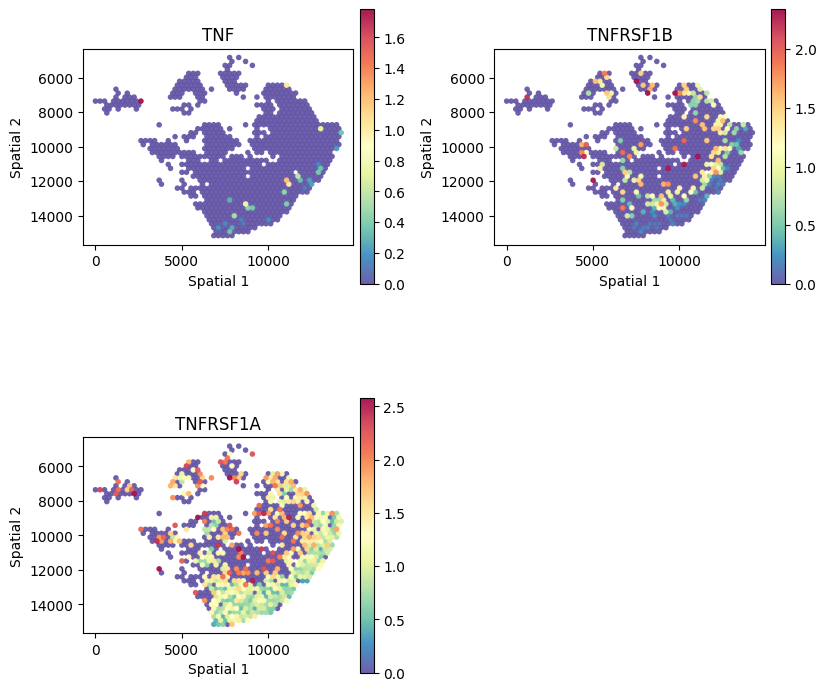

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\05_TNF_spot_pathway_scores.png


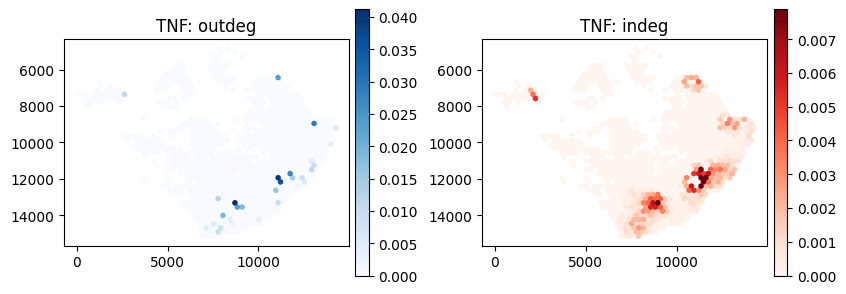

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\06_TNF_TNFRSF1B_spot_lr_scores.png


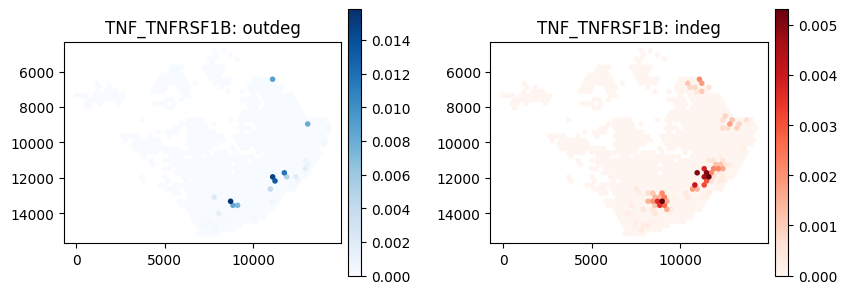

In [10]:
pathway_show = "TNF" if "TNF" in pathways else pathways[0]
pathway_rows = lr_candidates.loc[lr_candidates["pathway_name"].astype(str).eq(pathway_show)]
pathway_genes = pd.unique(pd.concat(
    [pathway_rows["ligand"], pathway_rows["receptor"]], ignore_index=True
).astype(str)).tolist()
pathway_genes = [gene for gene in pathway_genes if gene in cellchat.var_names]
if not pathway_genes:
    raise ValueError(f"No genes from signaling pathway {pathway_show!r} are present in the expression matrix.")

gene_indices = cellchat.var_names.get_indexer(pathway_genes)
gene_values = cellchat.X[:, gene_indices]
gene_values = gene_values.toarray() if sparse.issparse(gene_values) else np.asarray(gene_values)
gene_frame = pd.DataFrame(gene_values, index=cellchat.obs_names, columns=pathway_genes)

fig = cc.plot_spatial_values(
    cellchat, gene_frame, color_map="Spectral_r", quantile=0.99,
    point_size=16, ncol=2, return_fig=True,
)
save_fig(fig, f"04_{pathway_show}_spatial_expression.png")

fig = cc.plot_spot_signaling_scores(
    cellchat, signaling=pathway_show, measures=("outdeg", "indeg"),
    slot_name="spot_pathway_network", binary=False, quantile=0.99,
    point_size=16, return_fig=True,
)
save_fig(fig, f"05_{pathway_show}_spot_pathway_scores.png")

lr_show = pathway_rows.iloc[0]["interaction_name"]
fig = cc.plot_spot_signaling_scores(
    cellchat, signaling=lr_show, measures=("outdeg", "indeg"),
    slot_name="spot_network", binary=False, quantile=0.99,
    point_size=16, return_fig=True,
)
save_fig(fig, f"06_{lr_show}_spot_lr_scores.png")

### Communication between deconvolved cell groups

These panels use only the group pathway network produced by proportion-based
Visium aggregation. They summarize communication between six cell types.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\07_TNF_group_circle.png


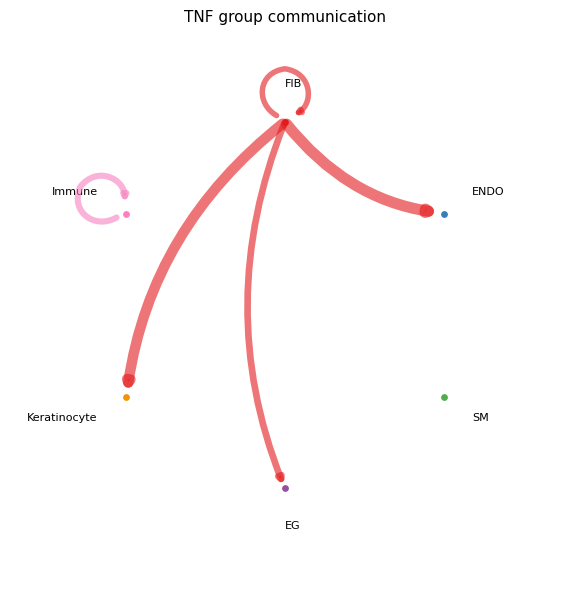

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\08_TNF_group_sender_receiver.png


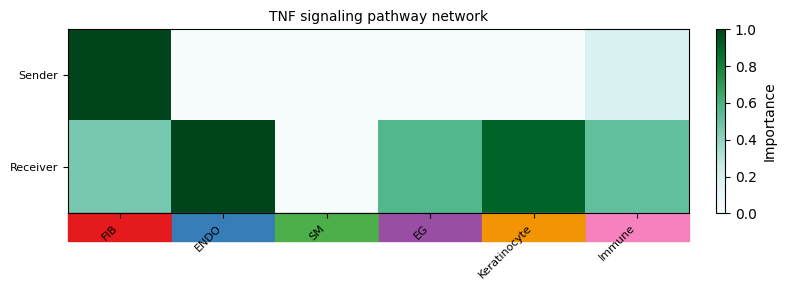

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\09_TNF_group_heatmap.png


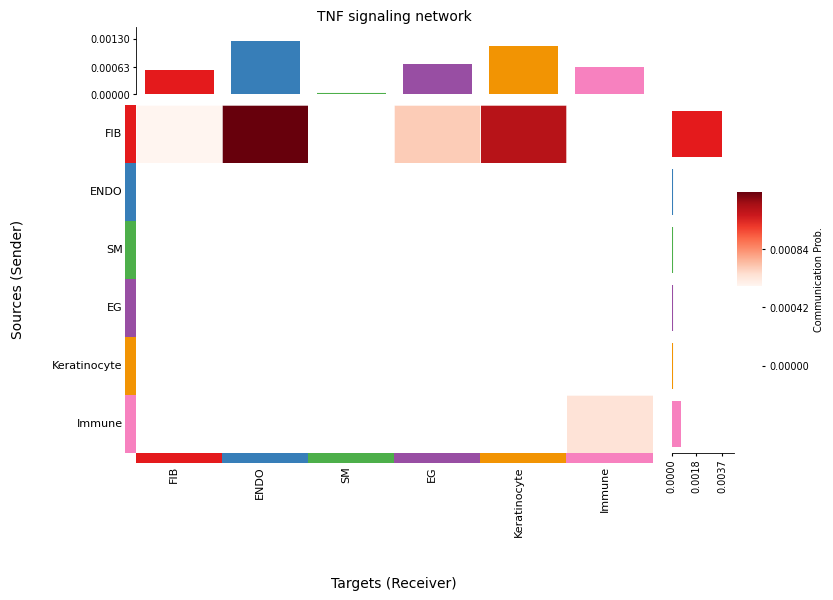

In [11]:
fig = cc.plot_network_aggregate(
    cellchat, signaling=pathway_show, layout="circle",
    title_name=f"{pathway_show} group communication", return_fig=True,
)
save_fig(fig, f"07_{pathway_show}_group_circle.png")

fig = cc.net_analysis_signaling_role_network(
    cellchat, signaling=pathway_show, slot_name="pathway_network",
    measure=("outdeg", "indeg"), measure_name=("Sender", "Receiver"),
    fig_size=(8, 3), return_fig=True,
)
save_fig(fig, f"08_{pathway_show}_group_sender_receiver.png")

fig = cc.plot_network_heatmap(
    cellchat, slot_name="pathway_network", signaling=pathway_show,
    color_heatmap="Reds", return_fig=True,
)
save_fig(fig, f"09_{pathway_show}_group_heatmap.png")

### Getis-Ord Gi hotspots

Incoming spot-level L-R degree is binarized and summed separately for Secreted
Signaling and Cell-Cell Contact. Significant positive Gi values are labelled
Hot, significant negative values Cold, and all remaining spots Other.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\10_secreted_signaling_gi.png


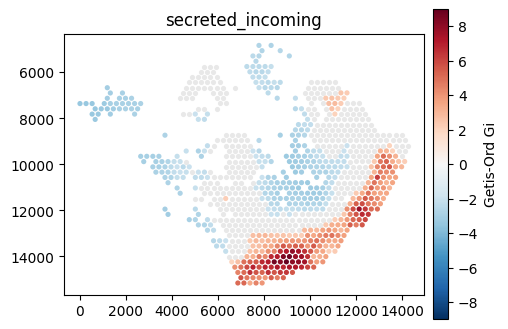

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\11_cell_contact_gi.png


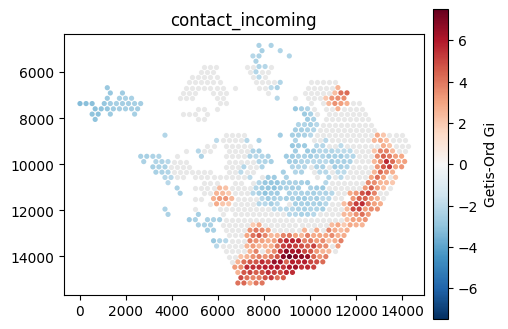

In [12]:
interaction_table = cellchat.spot_network["interactions"]
secreted_lr = interaction_table.loc[
    interaction_table["annotation"].eq("Secreted Signaling"), "interaction_name"
].astype(str).tolist()
contact_lr = interaction_table.loc[
    interaction_table["annotation"].eq("Cell-Cell Contact"), "interaction_name"
].astype(str).tolist()

cellchat = cc.compute_spatial_gi(
    cellchat, secreted_lr, measure="indeg", slot_name="spot_network",
    binary=True, n_neighbors=12, result_name="secreted_incoming",
)
cellchat = cc.compute_spatial_gi(
    cellchat, contact_lr, measure="indeg", slot_name="spot_network",
    binary=True, n_neighbors=12, result_name="contact_incoming",
)
fig = cc.plot_spatial_gi(cellchat, "secreted_incoming", pvalue=0.05, return_fig=True)
save_fig(fig, "10_secreted_signaling_gi.png")
fig = cc.plot_spatial_gi(cellchat, "contact_incoming", pvalue=0.05, return_fig=True)
save_fig(fig, "11_cell_contact_gi.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\12_secreted_hotspot_classes.png


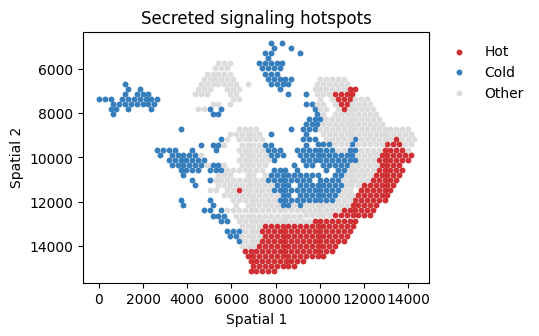

secreted_hotspot
Other    401
Cold     273
Hot      231
Name: count, dtype: int64


In [13]:
secreted_gi = cellchat.spatial_statistics["gi"]["secreted_incoming"]
secreted_hotspot = np.where(
    (secreted_gi["pvalue"].to_numpy() < 0.05) & (secreted_gi["gi"].to_numpy() > 0),
    "Hot",
    np.where(
        (secreted_gi["pvalue"].to_numpy() < 0.05) & (secreted_gi["gi"].to_numpy() < 0),
        "Cold", "Other",
    ),
)
cellchat.obs["secreted_hotspot"] = pd.Categorical(
    secreted_hotspot, categories=["Hot", "Cold", "Other"], ordered=True,
)
fig = cc.plot_spatial_categories(
    cellchat, "secreted_hotspot",
    color_use={"Hot": "#cb181d", "Cold": "#2171b5", "Other": "#d9d9d9"},
    point_size=18, title="Secreted signaling hotspots", return_fig=True,
)
save_fig(fig, "12_secreted_hotspot_classes.png")
print(cellchat.obs["secreted_hotspot"].value_counts())

### Lee spatial co-occurrence

The first matrix relates hotspot classes to annotated groups. The second tests
spatial co-occurrence between active CXCL genes and incoming L-R scores using
the distance-weighted interaction neighbourhood. The R tutorial uses IL17 as
the receiving pathway. This notebook tries IL17 first and then another active
inflammatory pathway because the supplied H5 data can contain too few IL17
sender spots to pass the same `min_spots=10` communication filter.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\13_hotspot_cell_group_lee.png


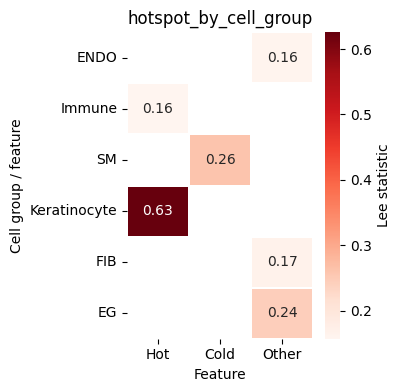

IL17 has no active spot-level L-R pairs after filtering; using IL1 for the Lee co-occurrence example.
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\14_cxcl_inflammatory_spatial_lee.png


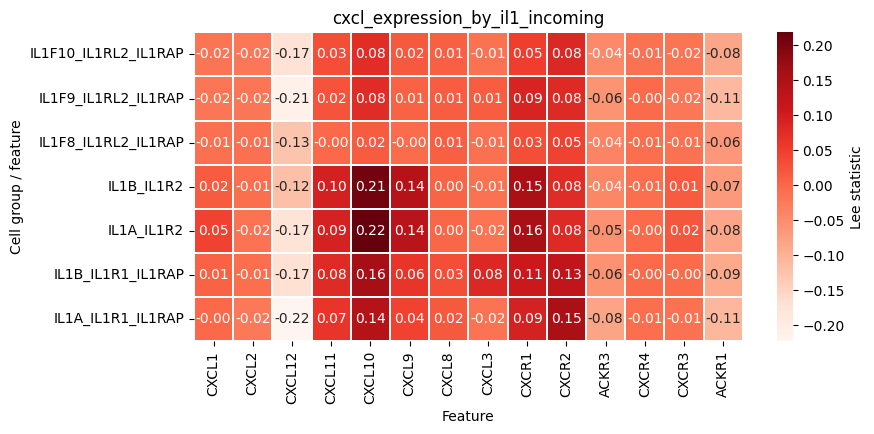

In [14]:
cellchat = cc.compute_spatial_lee(
    cellchat, x="secreted_hotspot", weight_type="identity",
    result_name="hotspot_by_cell_group",
)
fig = cc.plot_spatial_lee(
    cellchat, "hotspot_by_cell_group", cutoff=0.05,
    color_map="Reds", return_fig=True,
)
save_fig(fig, "13_hotspot_cell_group_lee.png")

cxcl_result = cc.extract_enriched_lr(
    cellchat, signaling="CXCL", gene_lr_return=True,
    slot_name="spot_network",
)
cxcl_genes = [gene for gene in cxcl_result["gene_lr"] if gene in cellchat.var_names]
cxcl_indices = cellchat.var_names.get_indexer(cxcl_genes)
cxcl_values = cellchat.X[:, cxcl_indices]
cxcl_values = cxcl_values.toarray() if sparse.issparse(cxcl_values) else np.asarray(cxcl_values)
cxcl_frame = pd.DataFrame(cxcl_values, index=cellchat.obs_names, columns=cxcl_genes)
cxcl_frame = cxcl_frame.loc[:, cxcl_frame.std(ddof=0) > 0]

receiver_pathway = None
receiver_lr = []
for pathway in ["IL17", "IL1", "CCL"]:
    pathway_result = cc.extract_enriched_lr(
        cellchat, signaling=pathway, slot_name="spot_network",
    )
    pathway_lr = pathway_result["interaction_name"].astype(str).tolist()
    pathway_lr = [
        name for name in pathway_lr
        if cellchat.spot_network["centrality"]["indeg"][name].std(ddof=0) > 0
    ]
    if pathway_lr:
        receiver_pathway = pathway
        receiver_lr = pathway_lr
        break
if receiver_pathway is None:
    raise ValueError("No active IL17, IL1, or CCL spot-level L-R pairs were available for Lee analysis.")
if receiver_pathway != "IL17":
    print(
        "IL17 has no active spot-level L-R pairs after filtering; "
        f"using {receiver_pathway} for the Lee co-occurrence example."
    )
receiver_incoming = cellchat.spot_network["centrality"]["indeg"].loc[:, receiver_lr]
cellchat = cc.compute_spatial_lee(
    cellchat, x=cxcl_frame, y=receiver_incoming, weight_type="interaction",
    interaction_range=interaction_range_um, contact_range=contact_range_um,
    result_name=f"cxcl_expression_by_{receiver_pathway.lower()}_incoming",
)
fig = cc.plot_spatial_lee(
    cellchat, f"cxcl_expression_by_{receiver_pathway.lower()}_incoming",
    color_map="Reds", return_fig=True,
)
save_fig(fig, "14_cxcl_inflammatory_spatial_lee.png")

---
## Part IV: Systems Analysis of Spatial Cell-Cell Communication

Identify communication topics from the spot-level network and rank pathways
in the aggregated group-level network.

### Communication topics

NMF factorizes the spot-by-L-R incoming centrality table into spot topic
weights and L-R loadings. Twelve topics follow the R example; a new dataset
should select topic number from diagnostics rather than copy it mechanically.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\15_incoming_topics_spatial.png


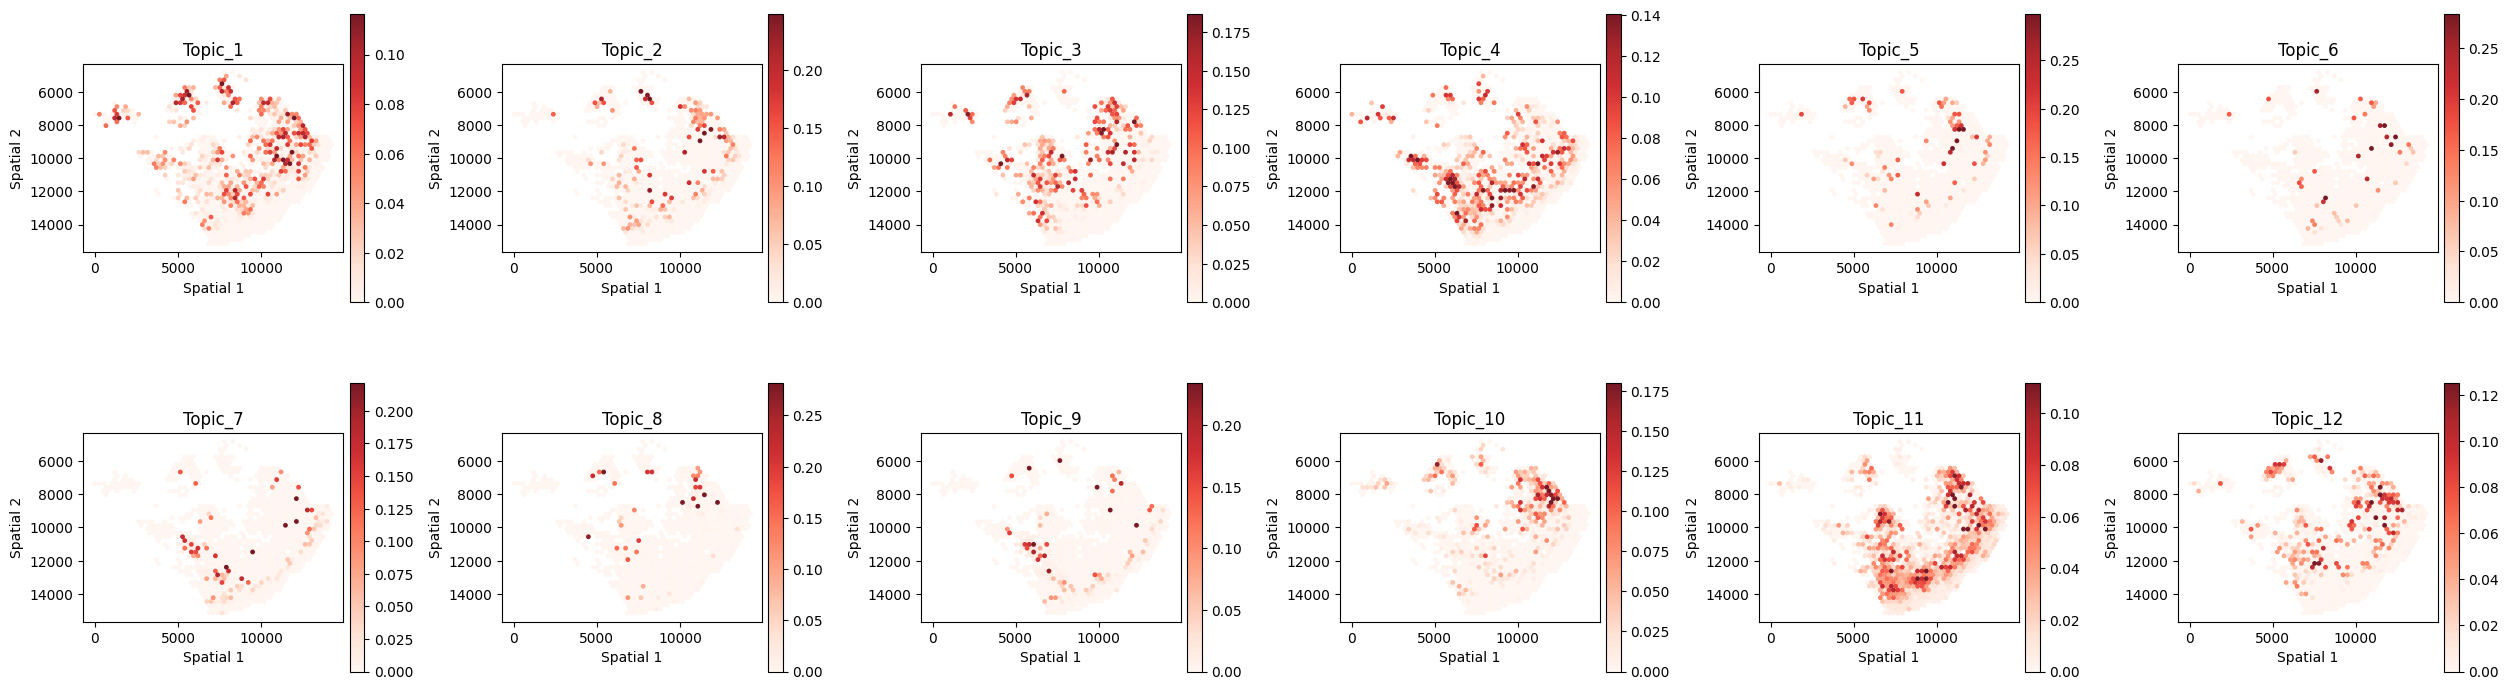

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\16_incoming_topic_composition.png


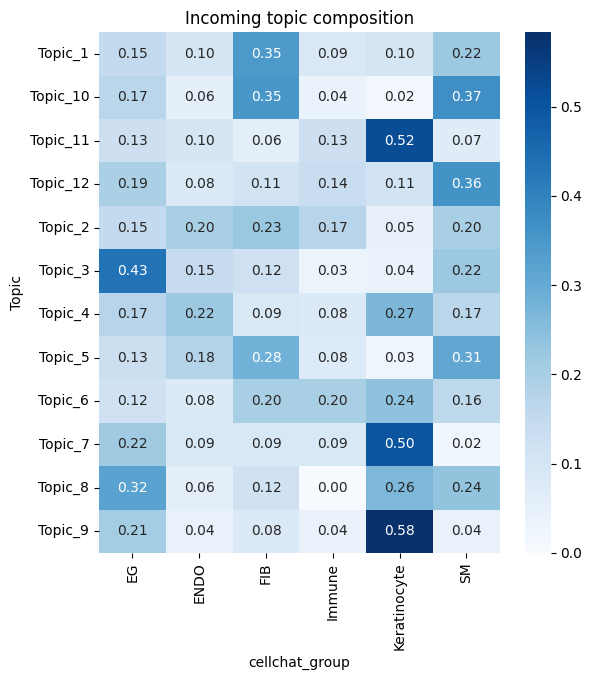

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\17_incoming_topic_signaling.png


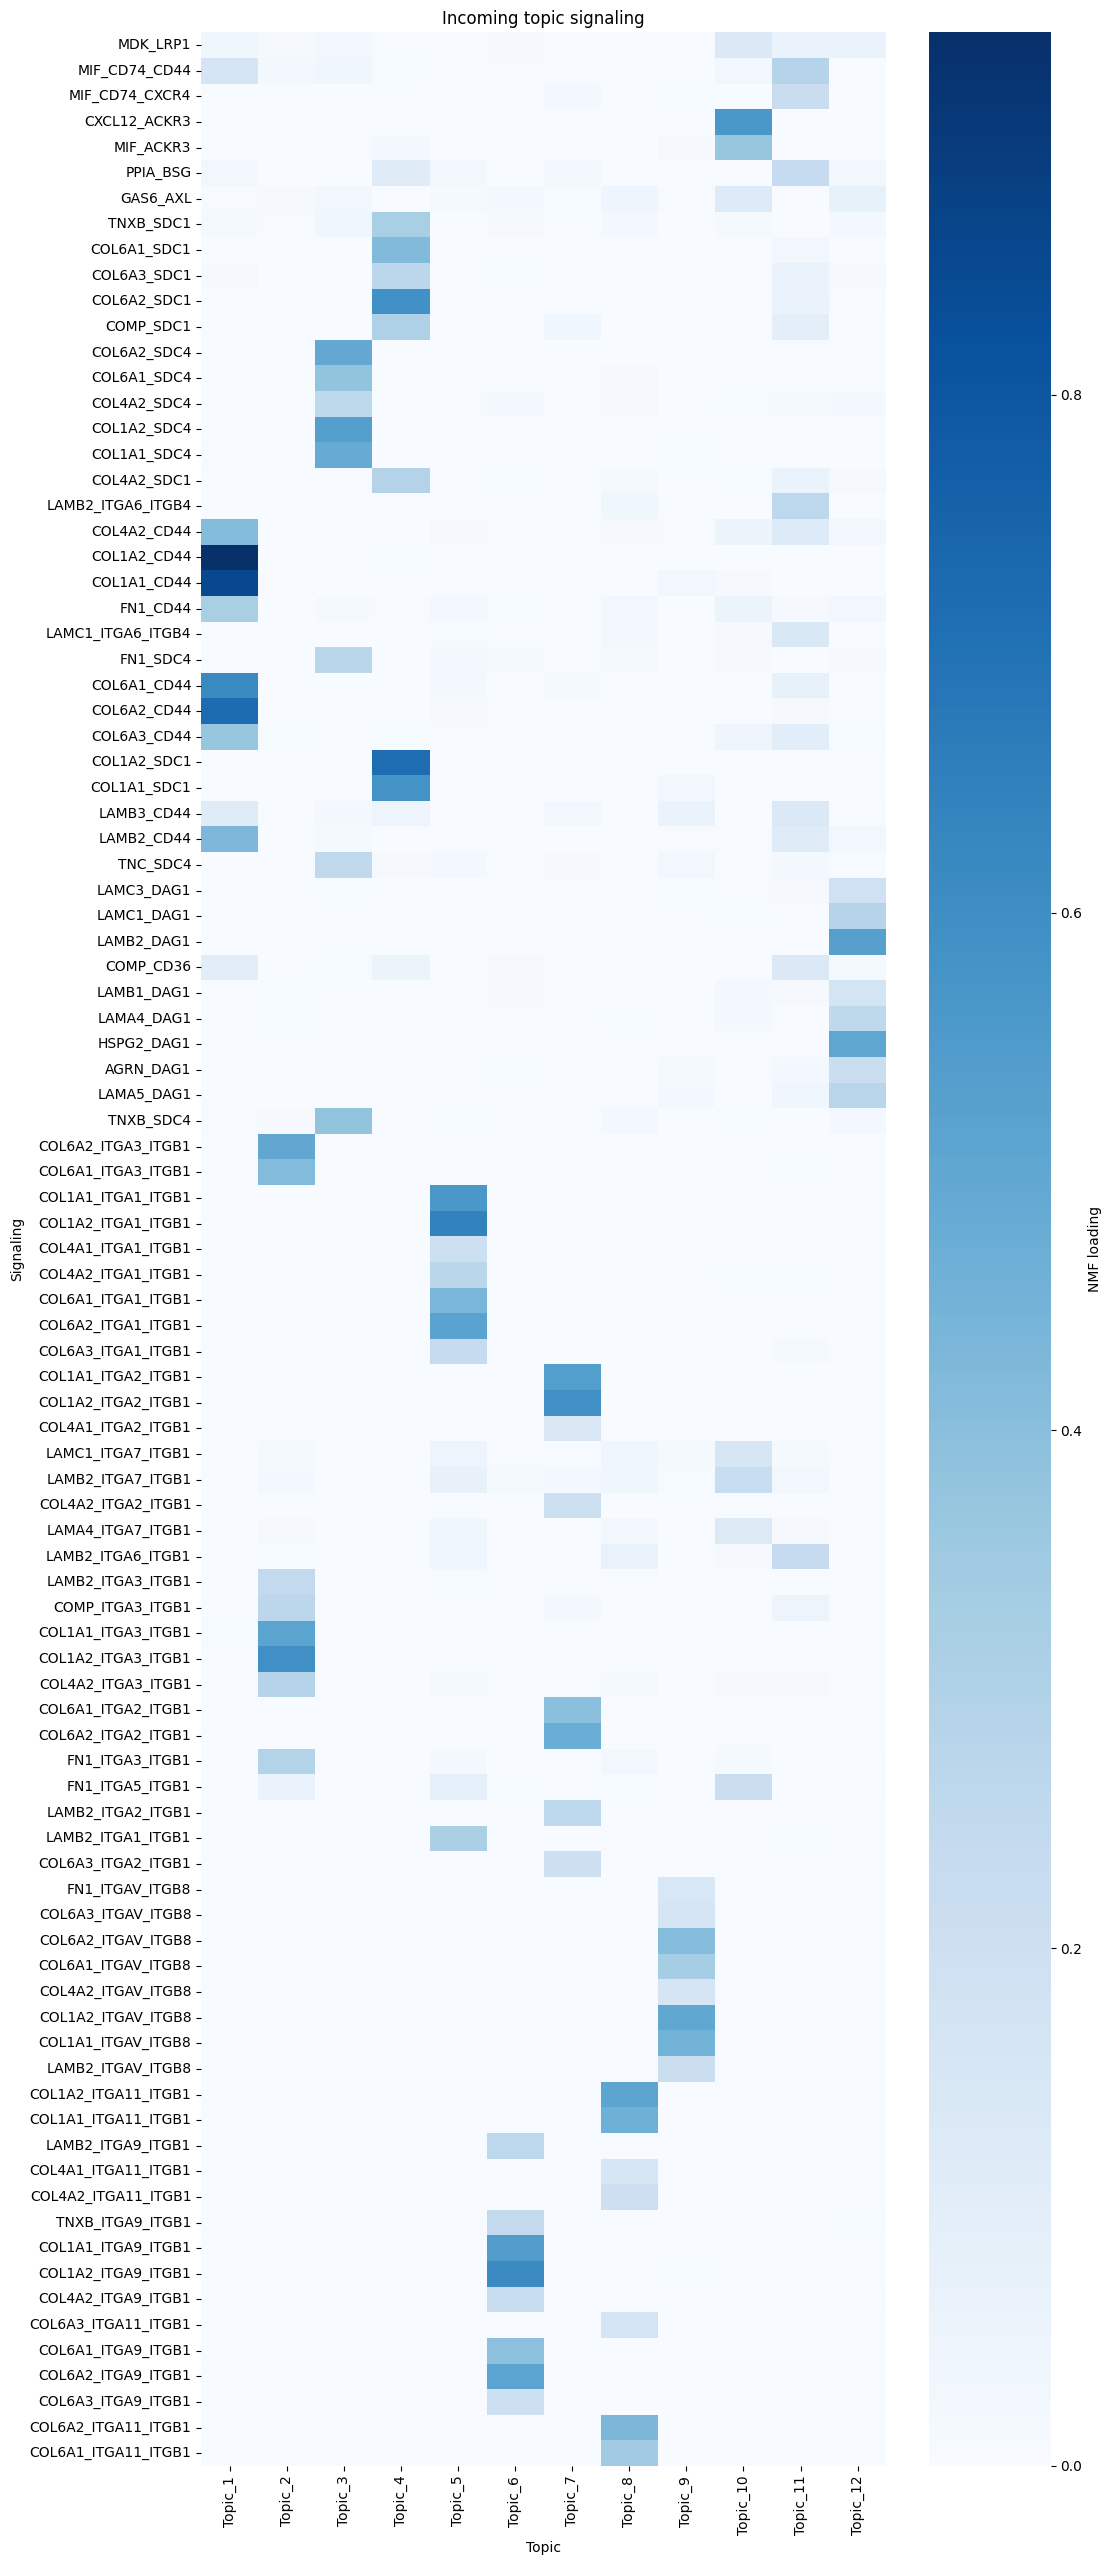

In [15]:
cellchat = cc.identify_cell_topics(
    cellchat, n_topics=topic_count, pattern="incoming",
    slot_name="spot_network", seed_use=topic_seed,
)
fig = cc.plot_spatial_topics(
    cellchat, slot_name="spot_network", pattern="incoming", color_map="Reds",
    quantile=0.99, point_size=12, ncol=6, return_fig=True,
)
save_fig(fig, "15_incoming_topics_spatial.png")

fig = cc.plot_topic_composition(
    cellchat, slot_name="spot_network", pattern="incoming",
    group_by="cellchat_group", return_fig=True,
)
save_fig(fig, "16_incoming_topic_composition.png")

fig = cc.plot_topic_signaling(
    cellchat, slot_name="spot_network", pattern="incoming",
    top_n=8, return_fig=True,
)
save_fig(fig, "17_incoming_topic_signaling.png")

### Rank group pathways and save all results

Pathway ranking uses the group network. Spatial statistics and topics remain
attached to the dedicated spot-level stores in the same serialized object.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\18_group_pathway_ranking_secreted.png


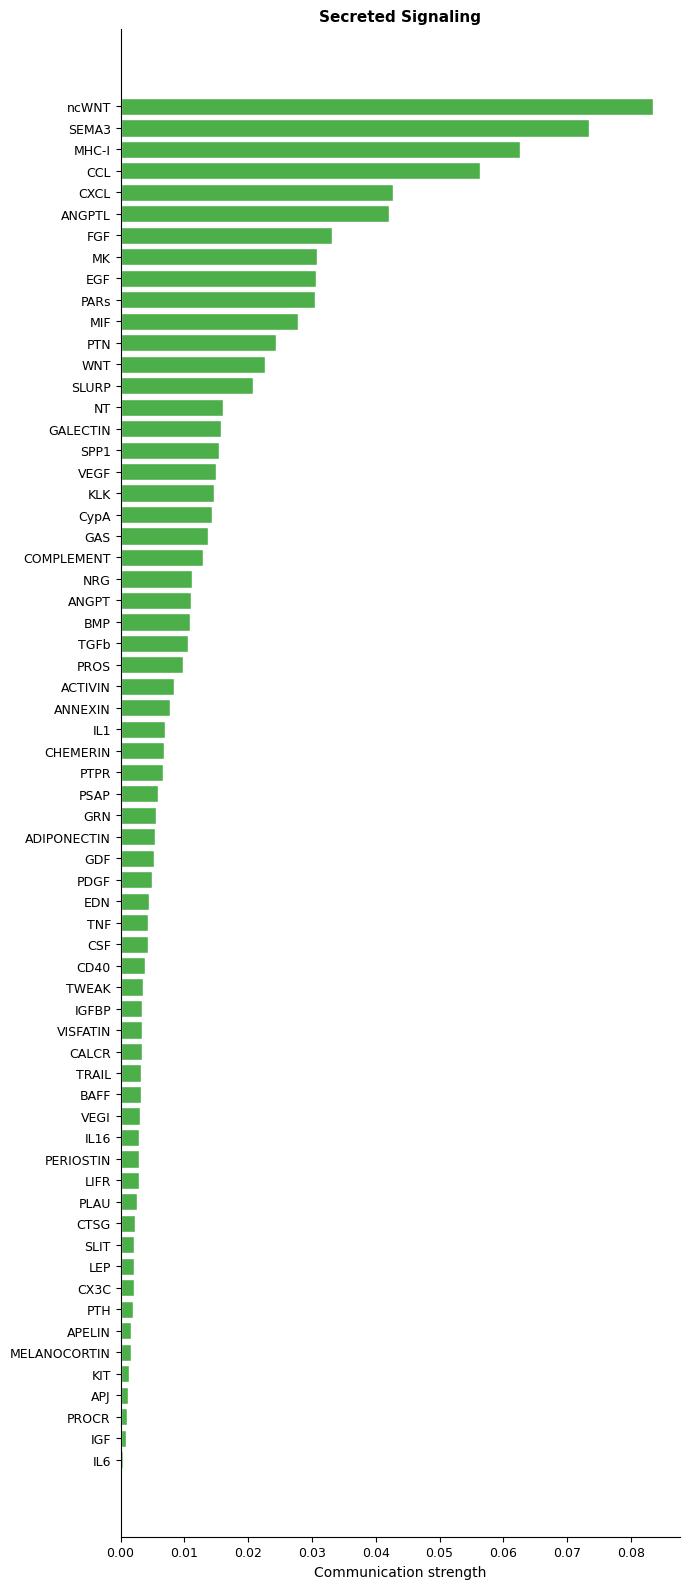

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\19_group_pathway_ranking_ecm.png


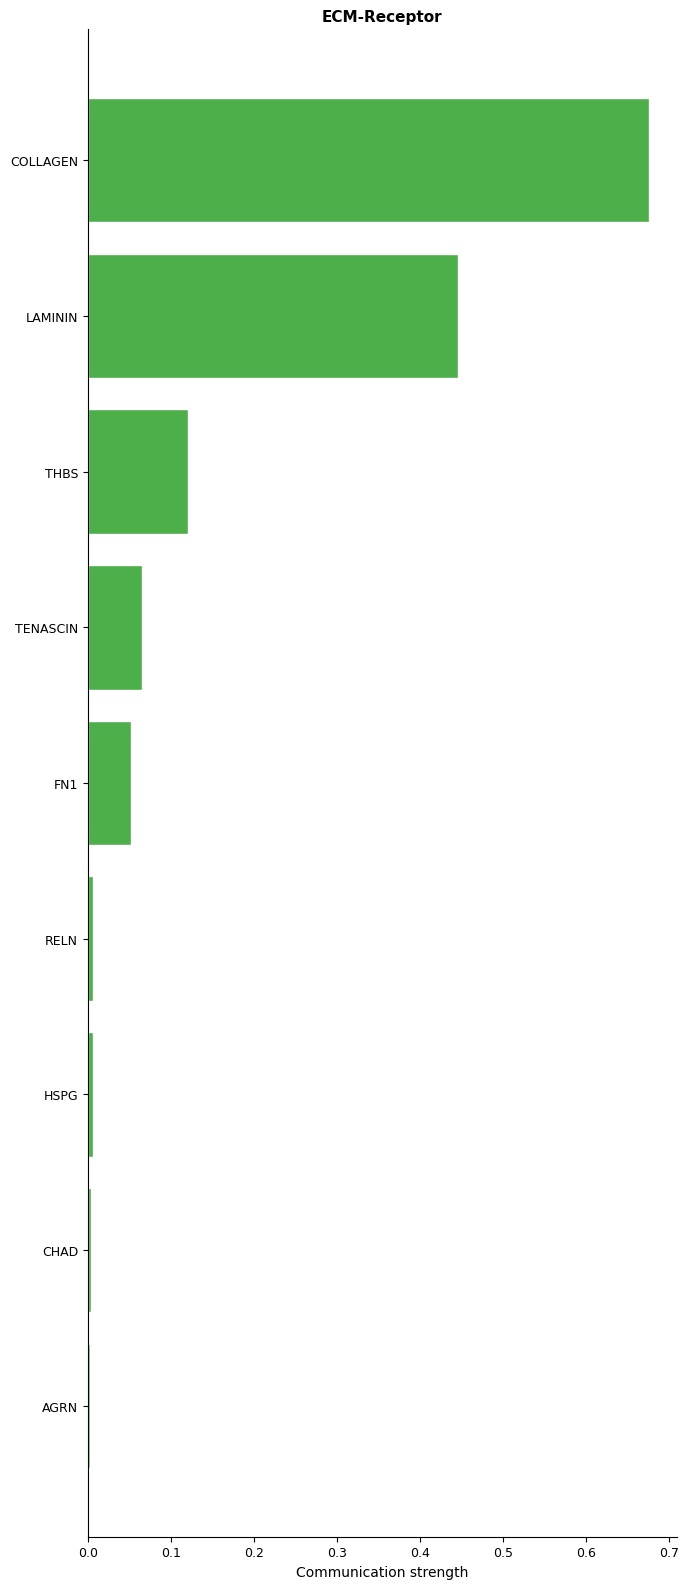

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\20_group_pathway_ranking_contact.png


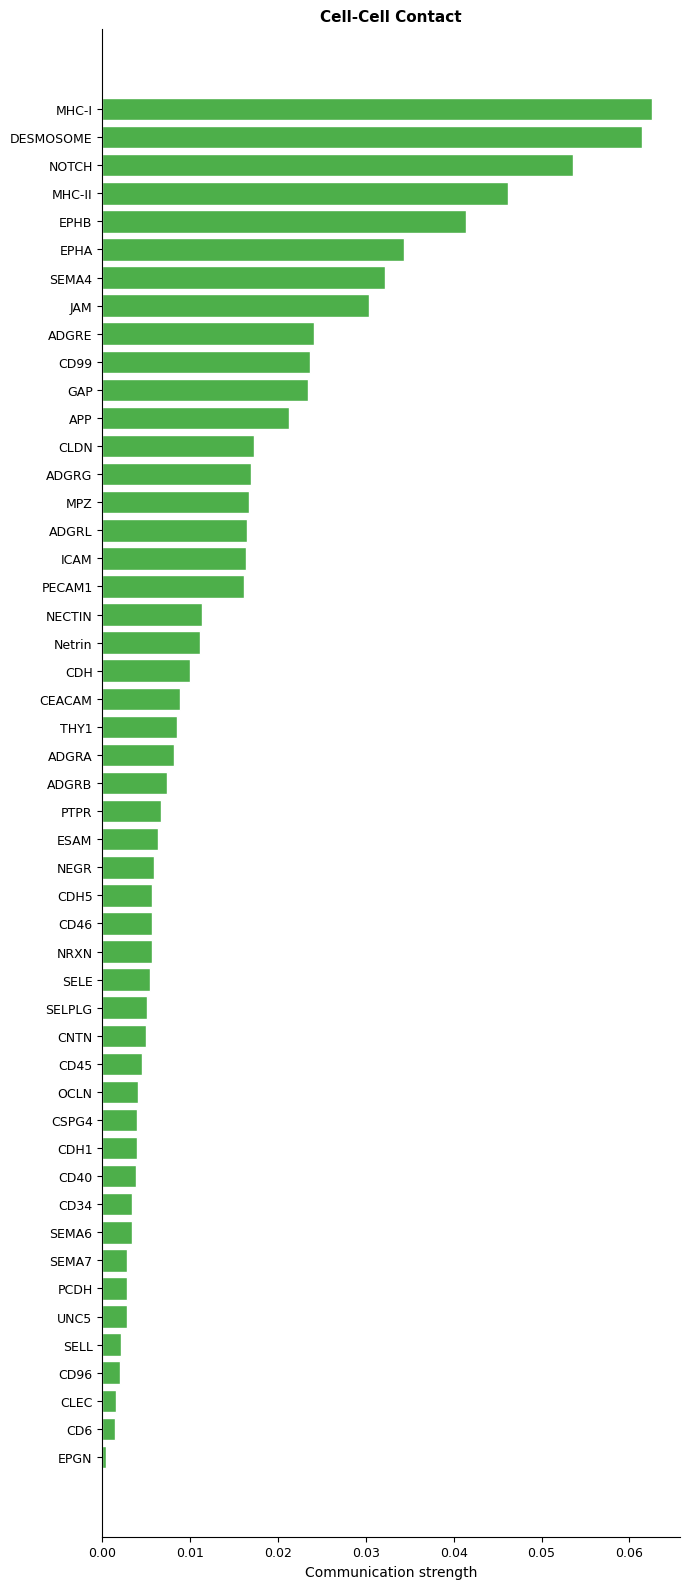

,pathway,score,signaling_type
0,IL6,0.000425,Secreted Signaling
1,IGF,0.000872,Secreted Signaling
2,PROCR,0.000928,Secreted Signaling
3,APJ,0.001102,Secreted Signaling
4,KIT,0.001374,Secreted Signaling
5,MELANOCORTIN,0.001588,Secreted Signaling
6,APELIN,0.001680,Secreted Signaling
7,PTH,0.001905,Secreted Signaling
8,CX3C,0.002118,Secreted Signaling
9,LEP,0.002160,Secreted Signaling


Completed in 69.6 s
Saved object: E:\Jin\cellchat.python_new\tutorial\spatial_tutorial_output\cellchat_psoriasis_spatial.pkl
Spot L-R matrices: 1624
Spot pathway matrices: 119
Group L-R matrices: 1624
Group pathway matrices: 119


In [16]:
rank_tables = []
for signaling_type, filename in [
    ("Secreted Signaling", "18_group_pathway_ranking_secreted.png"),
    ("ECM-Receptor", "19_group_pathway_ranking_ecm.png"),
    ("Cell-Cell Contact", "20_group_pathway_ranking_contact.png"),
]:
    fig = cc.rank_net(
        cellchat, mode="single", slot_name="pathway_network", measure="weight",
        signaling_type=signaling_type, title=signaling_type,
        fig_size=(7, 16), return_fig=True,
    )
    save_fig(fig, filename)
    rank_tables.append(
        cc.rank_net(
            cellchat, mode="single", slot_name="pathway_network", measure="weight",
            signaling_type=signaling_type, return_data=True,
        ).assign(signaling_type=signaling_type)
    )
rank_table = pd.concat(rank_tables, ignore_index=True)
display(rank_table.head(12))

topic_result = cellchat.cell_topics["spot_network"]["incoming"]
topic_result["cell"].to_csv(output_dir / "incoming_topic_spot_weights.csv")
topic_result["signaling"].to_csv(output_dir / "incoming_topic_lr_loadings.csv")
with (output_dir / "cellchat_psoriasis_spatial.pkl").open("wb") as handle:
    pickle.dump(cellchat, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Completed in {time.time() - analysis_start:.1f} s")
print(f"Saved object: {output_dir / 'cellchat_psoriasis_spatial.pkl'}")
print("Spot L-R matrices:", len(cellchat.spot_network["prob"]))
print("Spot pathway matrices:", len(cellchat.spot_pathway_network["prob"]))
print("Group L-R matrices:", len(cellchat.network["prob"]))
print("Group pathway matrices:", len(cellchat.pathway_network["prob"]))

## Interpretation notes

- A nonzero spot edge is a distance-allowed, expression-supported candidate,
  not direct proof of molecular transfer.
- Gi hotspots depend on the neighbourhood definition.
- Lee statistics describe spatial co-occurrence, not causality.
- Topics require joint interpretation of spatial weights and L-R loadings.
- Publication analyses should increase bootstrap repetitions, test sensitivity
  to spatial parameters, and validate conclusions in independent sections.